In [1]:
import pandas as pd
import numpy as np
dataset = pd.read_csv("titanic.csv")

In [2]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Write a function to check for missing values in the dataset.

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
dataset.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
#for age 
dataset['Age'] = dataset['Age'].fillna(dataset['Age'].median())

# Similarly for other columns
dataset['Cabin'] = dataset['Cabin'].fillna('Unknown')
dataset['Embarked'] = dataset['Embarked'].fillna(dataset['Embarked'].mode()[0])


In [7]:
dataset.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

# How would you encode the categorical variables "Sex" and "Embarked"?

In [11]:
from sklearn.preprocessing import LabelEncoder

# Instantiate the LabelEncoder
label_encoder = LabelEncoder()

# Encode 'Sex' column
dataset['Sex'] = label_encoder.fit_transform(dataset['Sex'])

# Encode 'Embarked' column (if it's ordinal, otherwise use one-hot encoding)
dataset['Embarked'] = label_encoder.fit_transform(dataset['Embarked'].fillna(dataset['Embarked'].mode()[0]))  # Handling missing values


In [13]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,Unknown,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,Unknown,2


# Create a new feature "FamilySize" using "SibSp" and "Parch". How does it impact survival?

In [16]:
dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1  # Add 1 for the passenger themselves



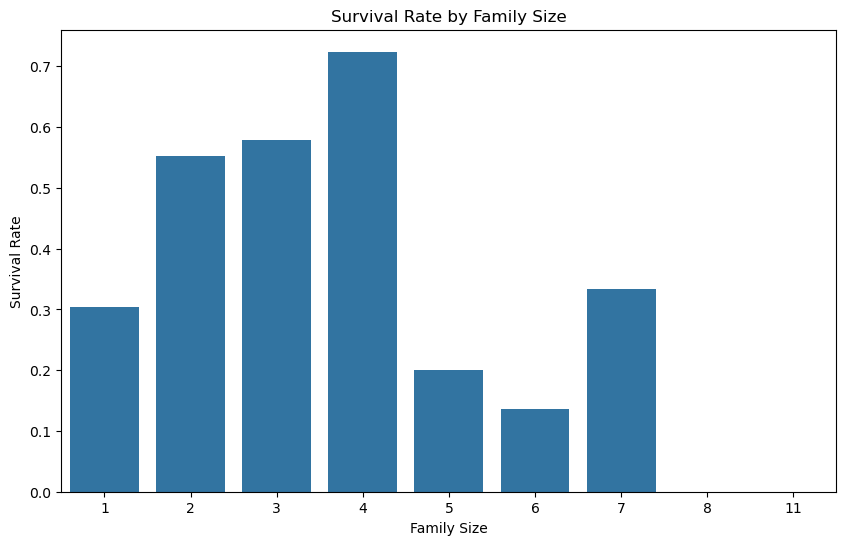

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group by 'FamilySize' and calculate the mean survival rate
family_size_survival = dataset.groupby('FamilySize')['Survived'].mean()

# Plotting the results
plt.figure(figsize=(10, 6))
sns.barplot(x=family_size_survival.index, y=family_size_survival.values)
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.show()


In [20]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,Unknown,2,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0,2
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,2,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2,2
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,Unknown,2,1


# Implement a function to extract the title (Mr, Mrs, Miss, etc.) from passenger names.

In [23]:
dataset['Title'] = dataset['Name'].str.extract(r'\b(Mr|Mrs|Miss|Master|Dr|Rev|Col|Major|Sir|Lady|Countess|Mme|Mlle|Ms)\b', expand=False)
dataset['Title'] = dataset['Title'].fillna('Unknown')

# Display the first few rows
print(dataset[['Name', 'Title']].head())


                                                Name Title
0                            Braund, Mr. Owen Harris    Mr
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs
2                             Heikkinen, Miss. Laina  Miss
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs
4                           Allen, Mr. William Henry    Mr


In [25]:
dataset.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Title
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,Unknown,2,2,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0,2,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,2,1,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,2,2,Mrs
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,Unknown,2,1,Mr


/var/folders/hf/wwv96j7x4k72h7npdvq8xbx80000gn/T/ipykernel_4009/3990139327.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fare_survival = dataset.groupby('FareRange')['Survived'].mean()


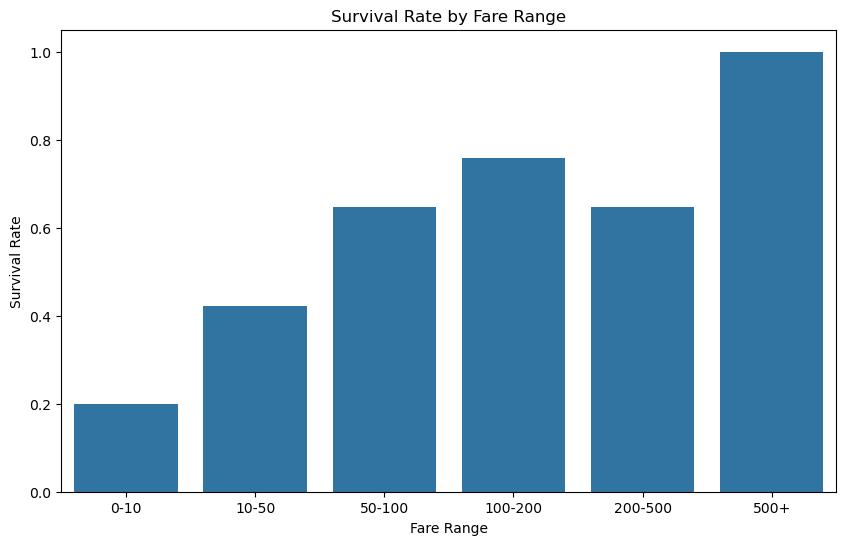

In [33]:
# Bucket the 'Fare' column into different price ranges
bins = [0, 10, 50, 100, 200, 500, float('inf')]  # Define price ranges
labels = ['0-10', '10-50', '50-100', '100-200', '200-500', '500+']  # Labels for the price ranges
dataset['FareRange'] = pd.cut(dataset['Fare'], bins=bins, labels=labels, right=False)

# Analyze survival rates for each fare range
fare_survival = dataset.groupby('FareRange')['Survived'].mean()

# Plotting the results
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(x=fare_survival.index, y=fare_survival.values)
plt.title('Survival Rate by Fare Range')
plt.xlabel('Fare Range')
plt.ylabel('Survival Rate')
plt.show()


In [35]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = dataset.drop(columns=['Survived'])  # Drop the 'Survived' column from features
y = dataset['Survived']  # Target variable

# Split the dataset into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shape of the resulting sets
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)


Training set shape: (712, 14)
Testing set shape: (179, 14)


In [37]:
# Calculate the number of survivors
num_survived = dataset['Survived'].sum()

# Display the result
print(f"Number of survivors: {num_survived}")


Number of survivors: 342
